# Imports

In [1]:
import time as tm
import numpy as np
import pandas as pd
import joblib as jb
import seaborn as sns
import gensim as gns
import optuna as opt
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

/home/victor/Documents/EngenhariaDeComputação/10-Semestre/INICIAÇÃO_CIENTÍFICA_II/src/sqlinjection/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Limpeza dos Dados

In [2]:
df = pd.read_csv('SQLiV3.csv', encoding='utf-8')

In [3]:
display(df)

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN
30915,DELETE FROM tomorrow,0,NaN,NaN
30916,SELECT wide ( s ) FROM west,0,NaN,NaN
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN


### Removendo tabelas que não serão utilizadas

In [4]:
df = df.drop(columns=['Unnamed: 2','Unnamed: 3'])
display(df)

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
...,...,...
30914,DELETE FROM door WHERE grow = 'small',0
30915,DELETE FROM tomorrow,0
30916,SELECT wide ( s ) FROM west,0
30917,SELECT * FROM ( SELECT slide FROM breath ),0


### Verificando a quantidade de valores ausentes e removendo eles

In [5]:
df.describe()

,Sentence,Label
count,30904,30664
unique,30872,42
top,#NAME?,0
freq,8,19268


In [6]:
df['Label'].isna().sum()

255

In [7]:
df = df.dropna()
df['Label'].isna().sum()

0

In [8]:
df.describe()

,Sentence,Label
count,30649,30649
unique,30627,28
top,#NAME?,0
freq,8,19268


### Removendo dados no target que não são 0 e nem 1 (Dados sujos)

In [9]:
display(df)

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
5,select name from syscolumns where id = ...,1
...,...,...
30914,DELETE FROM door WHERE grow = 'small',0
30915,DELETE FROM tomorrow,0
30916,SELECT wide ( s ) FROM west,0
30917,SELECT * FROM ( SELECT slide FROM breath ),0


In [10]:
df[~df['Label'].isin(['0', '1'])]

,Sentence,Label
193,1,SELECT *
195,x' and 1 = ( select count ( * ) from...,--
204,\',desc users
251,23 or 1 = 1,--
264,&apos,OR
362,x' AND userid IS NULL,--
377,x' and members.email is NULL,--
409,) ),waitfor delay '0:0:__TIME__'--
420,1' and 1 = ( select count ( * ) from...,--
447,,drop table temp --


In [11]:
df = df[df['Label'].isin(['0', '1'])]
display(df)

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
5,select name from syscolumns where id = ...,1
...,...,...
30914,DELETE FROM door WHERE grow = 'small',0
30915,DELETE FROM tomorrow,0
30916,SELECT wide ( s ) FROM west,0
30917,SELECT * FROM ( SELECT slide FROM breath ),0


### Convertendo o tipo da coluna Target para int

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30609 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sentence  30609 non-null  object
 1   Label     30609 non-null  object
dtypes: object(2)
memory usage: 717.4+ KB


In [13]:
df['Label'] = df['Label'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30609 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sentence  30609 non-null  object
 1   Label     30609 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 717.4+ KB


### Remover as linhas em que a coluna 'Sentence' está vazia

In [14]:
df = df[~df['Sentence'].str.strip().eq('')]

### Usar o Lower nas Linhas da coluna 'Sentence'

In [15]:
df['Sentence'] = df['Sentence'].str.lower()
display(df)

,Sentence,Label
0,""" or pg_sleep ( __time__ ) --",1
2,and 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
5,select name from syscolumns where id = ...,1
...,...,...
30914,delete from door where grow = 'small',0
30915,delete from tomorrow,0
30916,select wide ( s ) from west,0
30917,select * from ( select slide from breath ),0


### Exportando dataset higienizado

In [16]:
df.to_csv('SQLiV3_Clean.csv', index=False)

### Countplot para verificar as quantidades em ambas as classes

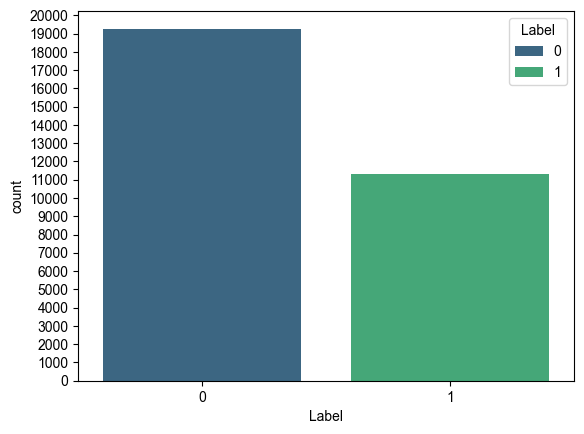

In [17]:
sns.countplot(x = 'Label', data=df, hue = 'Label', palette = 'viridis')
sns.set_theme(style="whitegrid")
plt.yticks(np.arange(0, 21000, 1000))
plt.show()

# Etapas do Treinamento

In [18]:
X = df['Sentence'].values
y = df['Label'].values

### Usando o TF-IDF para vetorizar os códigos de SQL

In [50]:
start_time = tm.time()
vectorizer = TfidfVectorizer(use_idf=True)
X_vectorizer = vectorizer.fit_transform(X)
end_time = tm.time()
print(f"Tempo de Vetorização: {end_time - start_time}")
#vectorizer = CountVectorizer(min_df = 100, max_df = 0.8, stop_words = 'english')
#X_vectorizer = vectorizer.fit_transform(X)

Tempo de Vetorização: 0.32964372634887695


### SMOTE (Cria amostra sintéticas da menor classe para balancear)

In [32]:
quantidades = np.bincount(y)

print("Quantidade de 0s:", quantidades[0])
print("Quantidade de 1s:", quantidades[1])

smote = SMOTE(random_state=7)
X_vectorizer, y = smote.fit_resample(X_vectorizer, y)

quantidades = np.bincount(y)

print("\nQuantidade de 0s:", quantidades[0])
print("Quantidade de 1s:", quantidades[1])

Quantidade de 0s: 19268
Quantidade de 1s: 11340

Quantidade de 0s: 19268
Quantidade de 1s: 19268


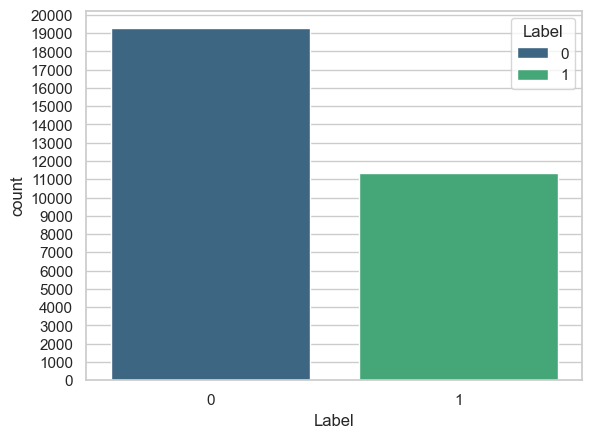

In [115]:
plot = pd.DataFrame(y, columns=["Label"])
sns.countplot(x = 'Label', data=plot, hue = 'Label', palette = 'viridis')
sns.set_theme(style="whitegrid")
plt.yticks(np.arange(0, 21000, 1000))
plt.show()

### Dividindo o dataset entre treinamento e teste

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorizer, y, test_size=0.2, random_state=7, shuffle=True)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24486, 24660)
(6122, 24660)
(24486,)
(6122,)


### Select Feature (Seleciona as melhores colunas/features que possuem mais impactos nos pesos sinápticos)
A grosso modo, ele cria um modelo como cobaia (nesse caso o LinearSVC)\
para ver quais colunas/features são mais efetivas, retirando as que tem menos impacto\
Pode aumentar a acurácia se estiver evitando colunas que mais atrapalham do que ajudam\
Evitando ruídos por exemplo.

In [52]:
# Criar uma instância do classificador LinearSVC()
clf = LinearSVC()

# Treinar o classificador no seu conjunto de dados
clf.fit(X_train, y_train)

# Selecionar as características mais importantes
sfm = SelectFromModel(clf, threshold=0.40)   #0.40 / 0.90
sfm.fit(X_train, y_train)

# Aplicar a transformação às suas características
X_train = sfm.transform(X_train)
X_test = sfm.transform(X_test)

### 1º Treinamento do Random Forest (Com SMOTE e sem FEATURE SELECTION)

In [24]:
seed = 7

In [25]:
model_rf = RandomForestClassifier(n_estimators = 50, random_state = seed).fit(X_train, y_train)
print(model_rf.score(X_test, y_test), '\n')
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

0.8225220550077841 

              precision    recall  f1-score   support

           0       1.00      0.65      0.78      3853
           1       0.74      1.00      0.85      3855

    accuracy                           0.82      7708
   macro avg       0.87      0.82      0.82      7708
weighted avg       0.87      0.82      0.82      7708



[[2488 1365]
 [   3 3852]]


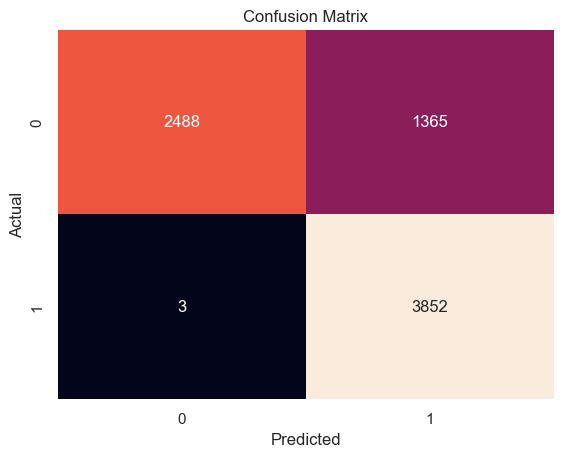

In [26]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Curvas de Aprendizado

Curvas de aprendizado mostram como a performance do modelo muda com o tamanho do conjunto de dados de treinamento. Plotar essas curvas pode ajudar a visualizar se o modelo está overfitting.
* Curva de Treinamento vs. Curva de Validação: Se a curva de treinamento continua melhorando enquanto a curva de validação estagna ou piora, isso é um sinal de overfitting.

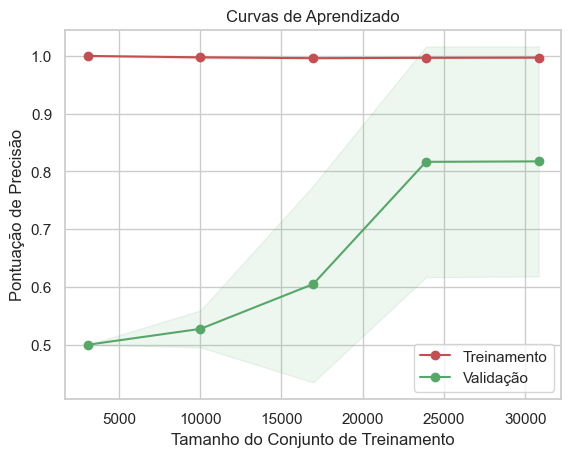

In [27]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Pontuação de Precisão')
plt.title('Curvas de Aprendizado')
plt.legend(loc='best')
plt.show()

### Comparar a Performance nos Dados de Treinamento e Teste

Uma das maneiras mais diretas de verificar o overfitting é comparar a performance do modelo nos dados de treinamento e nos dados de teste (ou validação). Alta Performance nos Dados de Treinamento e Baixa Performance nos Dados de Teste: Se o modelo tem uma precisão alta nos dados de treinamento, mas uma precisão significativamente menor nos dados de teste, isso é um sinal claro de overfitting.

In [28]:
y_train_pred = model_rf.predict(X_train)
y_test_pred = model_rf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Acurácia do Treinamento: {train_accuracy}")
print(f"Acurácia do Teste: {test_accuracy}")
print(f"Diferença de acurácia: {train_accuracy - test_accuracy}")

Acurácia do Treinamento: 0.996561567406254
Acurácia do Teste: 0.8225220550077841
Diferença de acurácia: 0.17403951239846993


### A curva ROC é uma ferramenta útil para avaliar o desempenho de um modelo de classificação binária, especialmente quando se lida com problemas desbalanceados

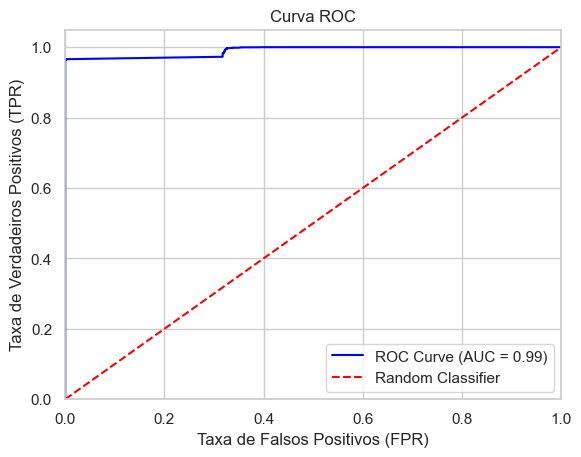

In [29]:
y_proba = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 2º Treinamento do Random Forest (Com SMOTE e Com FEATURE SELECTION)

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(30828, 6058)
(7708, 6058)
(30828,)
(7708,)


In [35]:
model_rf = RandomForestClassifier(n_estimators = 50, random_state = seed).fit(X_train, y_train)
print(model_rf.score(X_test, y_test), '\n')
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

0.99429164504411 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3853
           1       1.00      0.99      0.99      3855

    accuracy                           0.99      7708
   macro avg       0.99      0.99      0.99      7708
weighted avg       0.99      0.99      0.99      7708



[[3845    8]
 [  36 3819]]


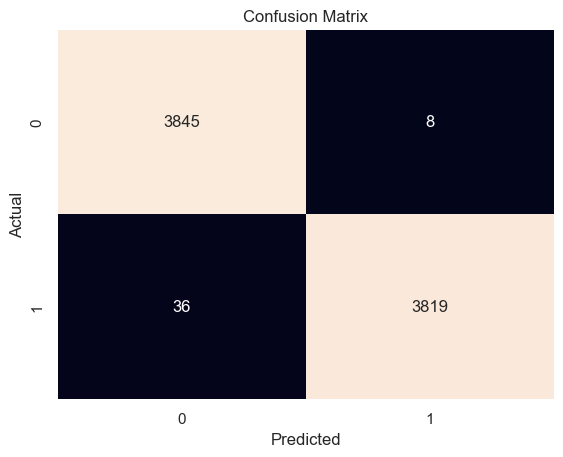

In [36]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Média das Profundidades das Árvores

In [37]:
depths = [tree.tree_.max_depth for tree in model_rf.estimators_]
soma = 0
menor = float('inf')
maior = float('-inf')
cnt = 0

for i, depth in enumerate(depths):
    #print(f"Árvore {i}: Profundidade = {depth}")
    soma += depth
    cnt += 1
    if(depth < menor):
        menor = depth
    if(depth > maior):
        maior = depth

print(f"MENOR PROFUNDIDADE: {menor}")
print(f"MAIOR PROFUNDIDADE: {maior}")
print(f"\nMÉDIA DAS PROFUNDIDADES: {round(soma/cnt)}")

MENOR PROFUNDIDADE: 2920
MAIOR PROFUNDIDADE: 3104

MÉDIA DAS PROFUNDIDADES: 3003


### Curvas de Aprendizado

Curvas de aprendizado mostram como a performance do modelo muda com o tamanho do conjunto de dados de treinamento. Plotar essas curvas pode ajudar a visualizar se o modelo está overfitting.
* Curva de Treinamento vs. Curva de Validação: Se a curva de treinamento continua melhorando enquanto a curva de validação estagna ou piora, isso é um sinal de overfitting.

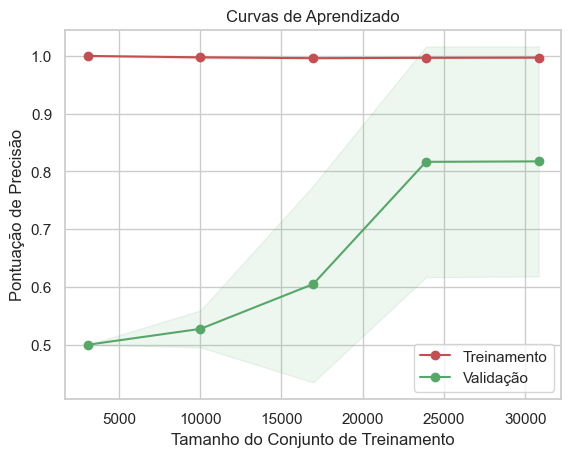

In [38]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Pontuação de Precisão')
plt.title('Curvas de Aprendizado')
plt.legend(loc='best')
plt.show()

### Comparar a Performance nos Dados de Treinamento e Teste

Uma das maneiras mais diretas de verificar o overfitting é comparar a performance do modelo nos dados de treinamento e nos dados de teste (ou validação). Alta Performance nos Dados de Treinamento e Baixa Performance nos Dados de Teste: Se o modelo tem uma precisão alta nos dados de treinamento, mas uma precisão significativamente menor nos dados de teste, isso é um sinal claro de overfitting.

In [39]:
y_train_pred = model_rf.predict(X_train)
y_test_pred = model_rf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Acurácia do Treinamento: {train_accuracy}")
print(f"Acurácia do Teste: {test_accuracy}")
print(f"Diferença de acurácia: {train_accuracy - test_accuracy}")

Acurácia do Treinamento: 0.996983261969638
Acurácia do Teste: 0.99429164504411
Diferença de acurácia: 0.0026916169255279954


### A curva ROC é uma ferramenta útil para avaliar o desempenho de um modelo de classificação binária, especialmente quando se lida com problemas desbalanceados

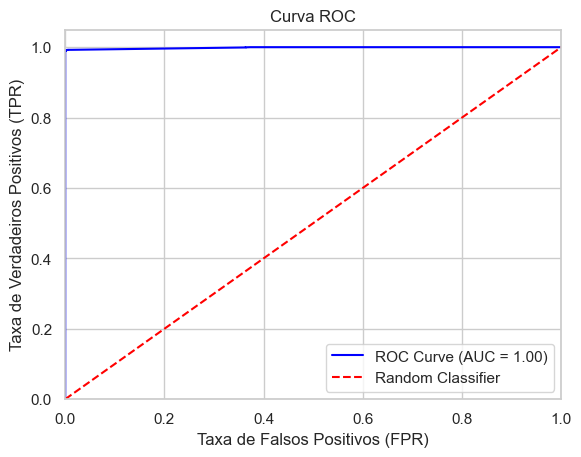

In [40]:
y_proba = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 2.1º Treinamento do Random Forest (Com Ajustes de Pesos(sem usar o SMOTE) e Com FEATURE SELECTION)

In [53]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24486, 1721)
(6122, 1721)
(24486,)
(6122,)


In [54]:
model_rf = RandomForestClassifier(n_estimators = 50, random_state = seed, class_weight="balanced").fit(X_train, y_train)
print(model_rf.score(X_test, y_test), '\n')
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

0.9959163672002613 

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3914
           1       1.00      0.99      0.99      2208

    accuracy                           1.00      6122
   macro avg       1.00      0.99      1.00      6122
weighted avg       1.00      1.00      1.00      6122



[[3913    1]
 [  24 2184]]


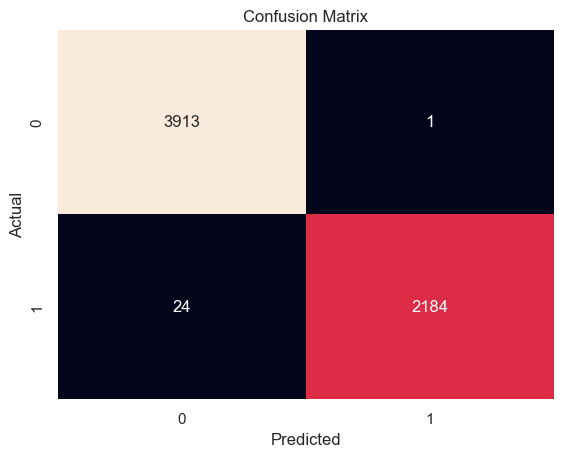

In [55]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Média das Profundidades das Árvores

In [56]:
depths = [tree.tree_.max_depth for tree in model_rf.estimators_]
soma = 0
menor = float('inf')
maior = float('-inf')
cnt = 0

for i, depth in enumerate(depths):
    #print(f"Árvore {i}: Profundidade = {depth}")
    soma += depth
    cnt += 1
    if(depth < menor):
        menor = depth
    if(depth > maior):
        maior = depth

print(f"MENOR PROFUNDIDADE: {menor}")
print(f"MAIOR PROFUNDIDADE: {maior}")
print(f"\nMÉDIA DAS PROFUNDIDADES: {round(soma/cnt)}")

MENOR PROFUNDIDADE: 113
MAIOR PROFUNDIDADE: 231

MÉDIA DAS PROFUNDIDADES: 162


### Curvas de Aprendizado

Curvas de aprendizado mostram como a performance do modelo muda com o tamanho do conjunto de dados de treinamento. Plotar essas curvas pode ajudar a visualizar se o modelo está overfitting.
* Curva de Treinamento vs. Curva de Validação: Se a curva de treinamento continua melhorando enquanto a curva de validação estagna ou piora, isso é um sinal de overfitting.

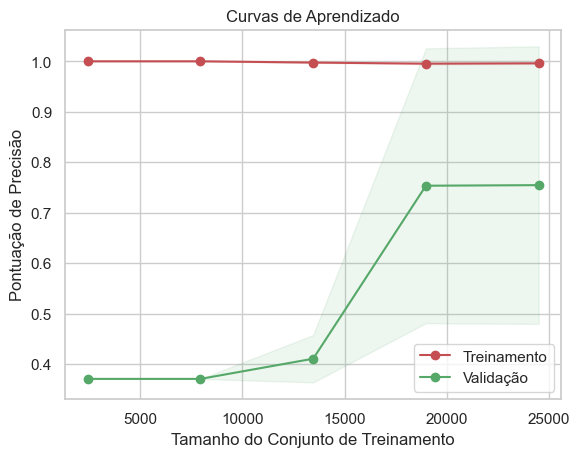

In [57]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Pontuação de Precisão')
plt.title('Curvas de Aprendizado')
plt.legend(loc='best')
plt.show()

### Comparar a Performance nos Dados de Treinamento e Teste

Uma das maneiras mais diretas de verificar o overfitting é comparar a performance do modelo nos dados de treinamento e nos dados de teste (ou validação). Alta Performance nos Dados de Treinamento e Baixa Performance nos Dados de Teste: Se o modelo tem uma precisão alta nos dados de treinamento, mas uma precisão significativamente menor nos dados de teste, isso é um sinal claro de overfitting.

In [58]:
y_train_pred = model_rf.predict(X_train)
y_test_pred = model_rf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Acurácia do Treinamento: {train_accuracy}")
print(f"Acurácia do Teste: {test_accuracy}")
print(f"Diferença de acurácia: {train_accuracy - test_accuracy}")

Acurácia do Treinamento: 0.9976312995180919
Acurácia do Teste: 0.9959163672002613
Diferença de acurácia: 0.0017149323178305975


### A curva ROC é uma ferramenta útil para avaliar o desempenho de um modelo de classificação binária, especialmente quando se lida com problemas desbalanceados

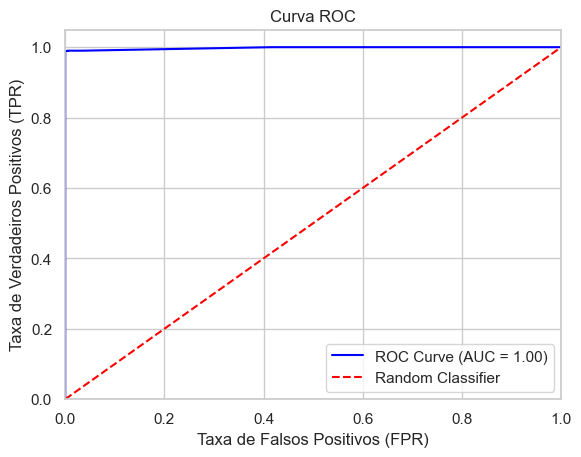

In [59]:
y_proba = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 3º Treinamento do Random Forest (Com SMOTE e Com FEATURE SELECTION e setando Max_Depth e Trees)

### Inicialização dos parâmetros para o treinamento do Random Forest

In [20]:
trees = 25
seed = 7
depth = 110

In [21]:
model_rf = RandomForestClassifier(max_depth=depth, n_estimators = trees, random_state = seed, class_weight="balanced").fit(X_train, y_train)
print(model_rf.score(X_test, y_test), '\n')
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

0.9781117281934009 

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3914
           1       1.00      0.94      0.97      2208

    accuracy                           0.98      6122
   macro avg       0.98      0.97      0.98      6122
weighted avg       0.98      0.98      0.98      6122



[[3911    3]
 [ 131 2077]]


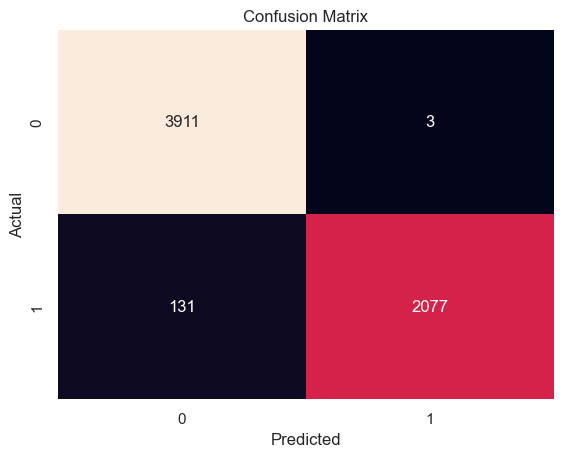

In [159]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Curvas de Aprendizado

Curvas de aprendizado mostram como a performance do modelo muda com o tamanho do conjunto de dados de treinamento. Plotar essas curvas pode ajudar a visualizar se o modelo está overfitting.
* Curva de Treinamento vs. Curva de Validação: Se a curva de treinamento continua melhorando enquanto a curva de validação estagna ou piora, isso é um sinal de overfitting.

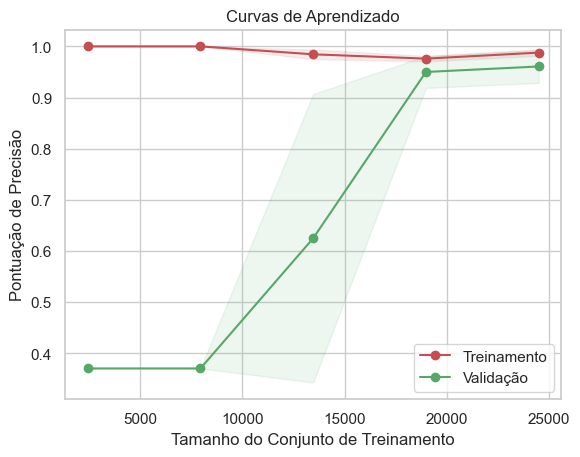

In [120]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Pontuação de Precisão')
plt.title('Curvas de Aprendizado')
plt.legend(loc='best')
plt.show()

### Comparar a Performance nos Dados de Treinamento e Teste

Uma das maneiras mais diretas de verificar o overfitting é comparar a performance do modelo nos dados de treinamento e nos dados de teste (ou validação). Alta Performance nos Dados de Treinamento e Baixa Performance nos Dados de Teste: Se o modelo tem uma precisão alta nos dados de treinamento, mas uma precisão significativamente menor nos dados de teste, isso é um sinal claro de overfitting.

In [121]:
y_train_pred = model_rf.predict(X_train)
y_test_pred = model_rf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Acurácia do Treinamento: {train_accuracy}")
print(f"Acurácia do Teste: {test_accuracy}")
print(f"Diferença de acurácia: {train_accuracy - test_accuracy}")

Acurácia do Treinamento: 0.9812954341256228
Acurácia do Teste: 0.9781117281934009
Diferença de acurácia: 0.0031837059322219474


### A curva ROC é uma ferramenta útil para avaliar o desempenho de um modelo de classificação binária, especialmente quando se lida com problemas desbalanceados

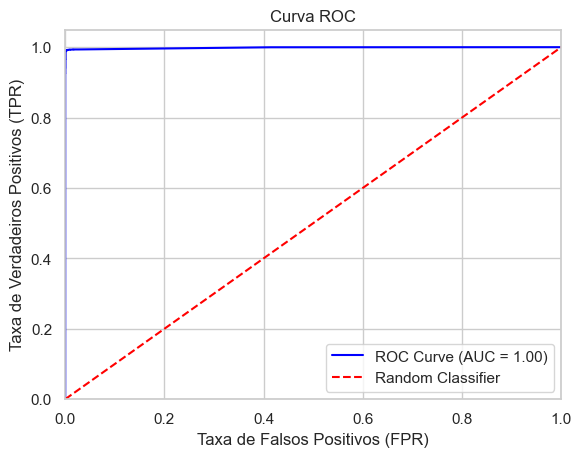

In [76]:
y_proba = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 4º Treinamento do Random Forest (Sem SMOTE e Com FEATURE SELECTION e setando Max_Depth e Trees)

In [95]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24487, 1742)
(6122, 1742)
(24487,)
(6122,)


In [96]:
trees = 25
seed = 7
depth = 110

In [97]:
model_rf = RandomForestClassifier(max_depth=depth, n_estimators = trees, random_state = seed).fit(X_train, y_train)
print(model_rf.score(X_test, y_test), '\n')
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

0.9949362953283241 

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3904
           1       1.00      0.99      0.99      2218

    accuracy                           0.99      6122
   macro avg       1.00      0.99      0.99      6122
weighted avg       0.99      0.99      0.99      6122



[[3899    5]
 [  26 2192]]


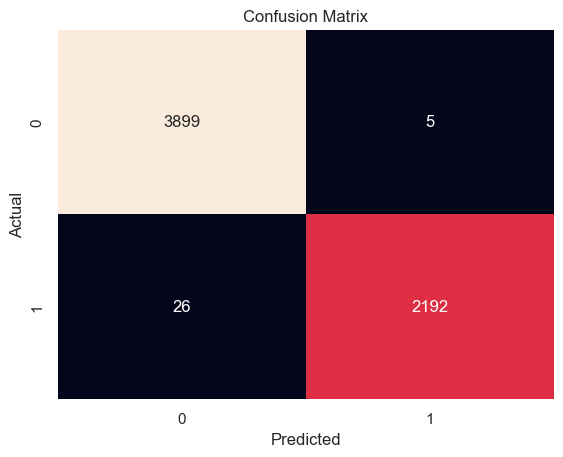

In [98]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Curvas de Aprendizado

Curvas de aprendizado mostram como a performance do modelo muda com o tamanho do conjunto de dados de treinamento. Plotar essas curvas pode ajudar a visualizar se o modelo está overfitting.
* Curva de Treinamento vs. Curva de Validação: Se a curva de treinamento continua melhorando enquanto a curva de validação estagna ou piora, isso é um sinal de overfitting.

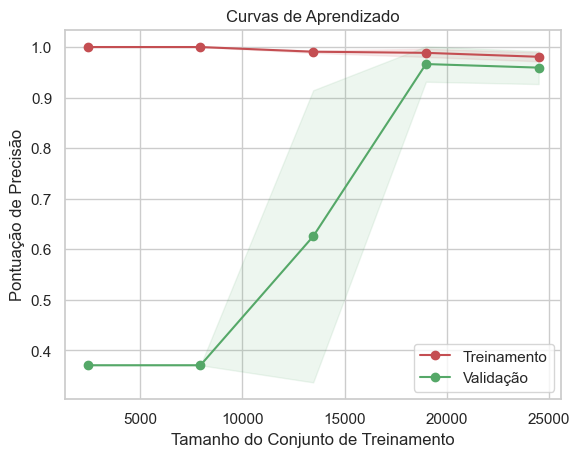

In [99]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Pontuação de Precisão')
plt.title('Curvas de Aprendizado')
plt.legend(loc='best')
plt.show()

### Comparar a Performance nos Dados de Treinamento e Teste

Uma das maneiras mais diretas de verificar o overfitting é comparar a performance do modelo nos dados de treinamento e nos dados de teste (ou validação). Alta Performance nos Dados de Treinamento e Baixa Performance nos Dados de Teste: Se o modelo tem uma precisão alta nos dados de treinamento, mas uma precisão significativamente menor nos dados de teste, isso é um sinal claro de overfitting.

In [100]:
y_train_pred = model_rf.predict(X_train)
y_test_pred = model_rf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Acurácia do Treinamento: {train_accuracy}")
print(f"Acurácia do Teste: {test_accuracy}")
print(f"Diferença de acurácia: {train_accuracy - test_accuracy}")

Acurácia do Treinamento: 0.9965696083636215
Acurácia do Teste: 0.9949362953283241
Diferença de acurácia: 0.0016333130352974568


### A curva ROC é uma ferramenta útil para avaliar o desempenho de um modelo de classificação binária, especialmente quando se lida com problemas desbalanceados

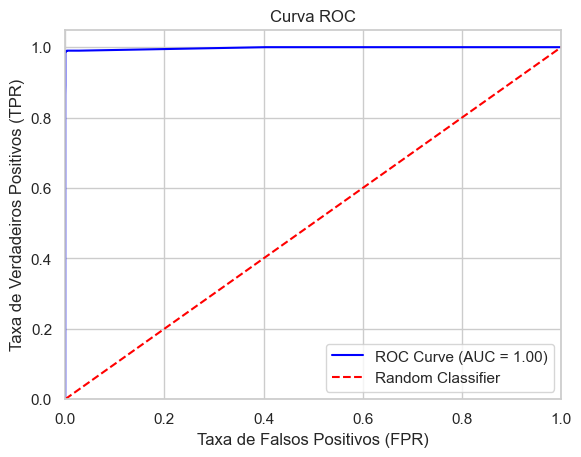

In [105]:
#y_scores = model_rf.predict_proba(X_test)[:, 1]
##fpr, tpr, thresholds = roc_curve(y_test, y_scores)
#roc_auc = roc_auc_score(y_test, y_scores)

#plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
#plt.plot([0, 1], [0, 1], color='red', linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('Falso Positivo')
#plt.ylabel('Verdadeiro Positivo')
#plt.title('Curva ROC')
#plt.legend(loc='lower right')
#plt.grid(True)
#plt.show()

y_proba = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 5º Treinamento do Random Forest (Com SMOTE e Com Feature Importance e setando Max_Depth e Trees)

In [22]:
importances = model_rf.feature_importances_
print(f"{len(importances)}\n")
#print(sorted(importances,reverse=True))

threshold = 2e-5

important_features = [feature for feature, importance in zip(vectorizer.get_feature_names_out() , importances) if importance >= threshold]
#print(type(X_train))
print(f"Variáveis importantes: {len(important_features)}\n")
#print(f"Variáveis importantes: {important_features}")

feature_names = vectorizer.get_feature_names_out()
important_indices = [list(feature_names).index(feature) for feature in important_features]

X_train_reduced = X_train[:, important_indices]
#X_train_reduced = X_train[important_features]
X_test_reduced = X_test[:, important_indices]

print(X_train_reduced.shape[1])

24660

Variáveis importantes: 1405

1405


In [23]:
trees = 10 #25 #10
seed = 7
depth = 80 #110 #90

In [25]:
start_time = tm.time()
model_rf = RandomForestClassifier(max_depth=depth, n_estimators = trees, random_state = seed).fit(X_train_reduced, y_train)
end_time = tm.time()
print(model_rf.score(X_test_reduced, y_test), '\n')
y_pred = model_rf.predict(X_test_reduced)
print(classification_report(y_test, y_pred))
print(f"Tempo de Treinamento: {end_time - start_time}")

0.9952629859523031 

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3914
           1       1.00      0.99      0.99      2208

    accuracy                           1.00      6122
   macro avg       1.00      0.99      0.99      6122
weighted avg       1.00      1.00      1.00      6122

Tempo de Treinamento: 0.22006750106811523


[[3911    3]
 [  26 2182]]


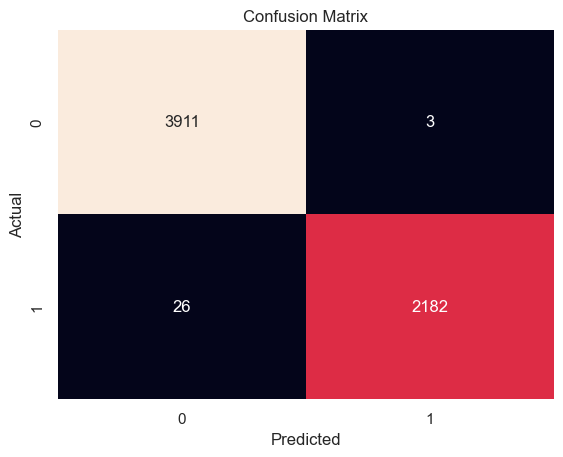

In [231]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Curvas de Aprendizado

Curvas de aprendizado mostram como a performance do modelo muda com o tamanho do conjunto de dados de treinamento. Plotar essas curvas pode ajudar a visualizar se o modelo está overfitting.
* Curva de Treinamento vs. Curva de Validação: Se a curva de treinamento continua melhorando enquanto a curva de validação estagna ou piora, isso é um sinal de overfitting.

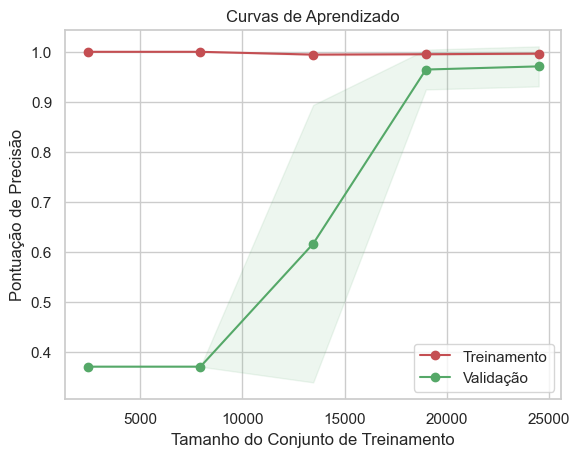

In [232]:
X_reduced = X_vectorizer[:, important_indices]

train_sizes, train_scores, test_scores = learning_curve(model_rf, X_reduced, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Pontuação de Precisão')
plt.title('Curvas de Aprendizado')
plt.legend(loc='best')
plt.show()

### Comparar a Performance nos Dados de Treinamento e Teste

Uma das maneiras mais diretas de verificar o overfitting é comparar a performance do modelo nos dados de treinamento e nos dados de teste (ou validação). Alta Performance nos Dados de Treinamento e Baixa Performance nos Dados de Teste: Se o modelo tem uma precisão alta nos dados de treinamento, mas uma precisão significativamente menor nos dados de teste, isso é um sinal claro de overfitting.

In [233]:
y_train_pred = model_rf.predict(X_train_reduced)
y_test_pred = model_rf.predict(X_test_reduced)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Acurácia do Treinamento: {train_accuracy}")
print(f"Acurácia do Teste: {test_accuracy}")
print(f"Diferença de acurácia: {train_accuracy - test_accuracy}")

Acurácia do Treinamento: 0.9958751939884015
Acurácia do Teste: 0.9952629859523031
Diferença de acurácia: 0.000612208036098405


### A curva ROC é uma ferramenta útil para avaliar o desempenho de um modelo de classificação binária, especialmente quando se lida com problemas desbalanceados

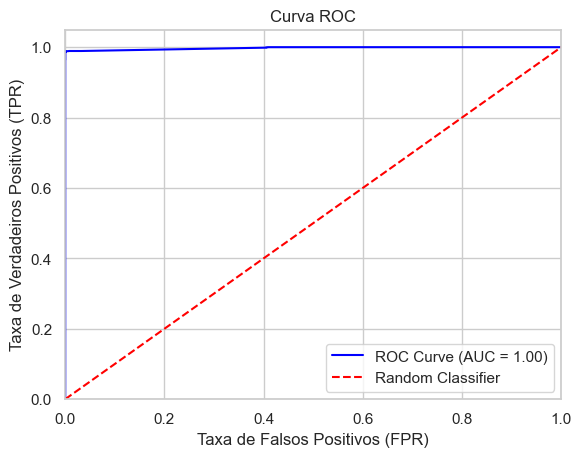

In [234]:
y_proba = model_rf.predict_proba(X_test_reduced)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Exportando Modelo

In [235]:
jb.dump(model_rf, 'modelo_sql_injection_reduced.pkl')
jb.dump(vectorizer, 'vectorizer_tfidf.pkl')
jb.dump(important_indices, 'important_indices.pkl')

['important_indices.pkl']

# Embeddings (Word2Vec)

In [19]:
sentences = [row.split() for row in df['Sentence']]

In [20]:
start_time = tm.time()
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, seed = 0)
end_time = tm.time()
print(f"Tempo de Vetorização: {end_time - start_time}")

Tempo de Vetorização: 1.7524993419647217


In [37]:
model.wv.save_word2vec_format("vetores.bin", binary=True)

In [21]:
def get_average_vector(text):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

In [22]:
X = np.array([get_average_vector(text) for text in df['Sentence']])
y = df['Label'].values

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [24]:
#smote = SMOTE(random_state=24)
#X_train, y_train = smote.fit_resample(X_train, y_train)
#X_test, y_test = smote.fit_resample(X_test, y_test)

In [25]:
start_time = tm.time()
#model_rf = RandomForestClassifier(n_estimators=50, max_depth= 50, random_state=9, class_weight="balanced").fit(X_train, y_train)
model_rf = RandomForestClassifier(n_estimators=7, max_depth= 12, random_state=7, class_weight="balanced").fit(X_train, y_train)
end_time = tm.time()
print(f"Tempo de Treinamento: {end_time - start_time}")

Tempo de Treinamento: 1.8496007919311523


In [26]:
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3914
           1       1.00      0.99      0.99      2208

    accuracy                           0.99      6122
   macro avg       1.00      0.99      0.99      6122
weighted avg       0.99      0.99      0.99      6122



[[3905    9]
 [  23 2185]]


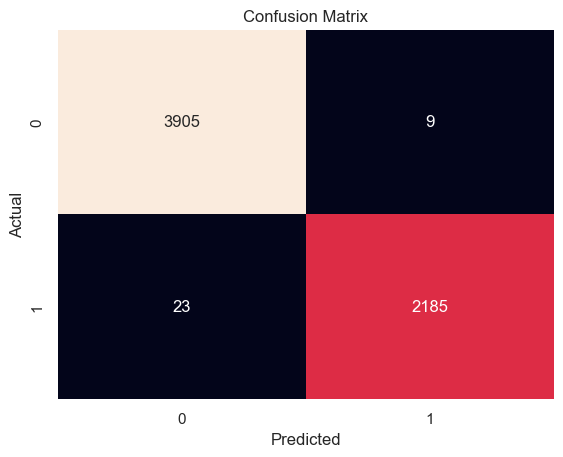

In [27]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

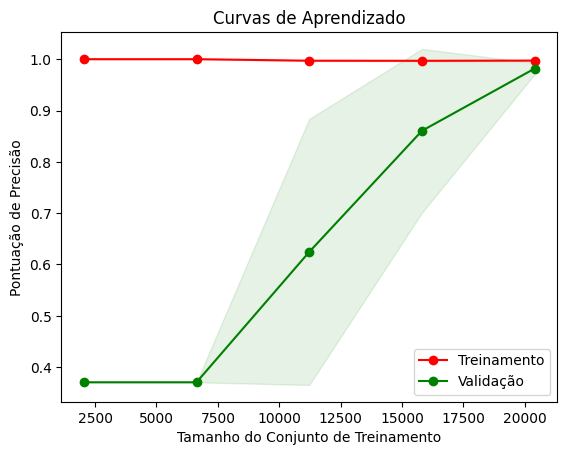

In [26]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X, y, cv=3, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Pontuação de Precisão')
plt.title('Curvas de Aprendizado')
plt.legend(loc='best')
plt.show()

In [29]:
y_train_pred = model_rf.predict(X_train)
y_test_pred = model_rf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Acurácia do Treinamento: {train_accuracy}")
print(f"Acurácia do Teste: {test_accuracy}")
print(f"Diferença de acurácia: {train_accuracy - test_accuracy}")

Acurácia do Treinamento: 0.9972637425467614
Acurácia do Teste: 0.9947729500163345
Diferença de acurácia: 0.002490792530426944


In [30]:
scores = cross_val_score(model_rf, X_train, y_train, cv=5, scoring="accuracy")
print(f"Validação Cruzada Scores: {scores}")
print(f"Média da Validação Cruzada: {scores.mean()}")

Validação Cruzada Scores: [0.99224173 0.99489483 0.99407801 0.99469063 0.99591587]
Média da Validação Cruzada: 0.9943642131210406


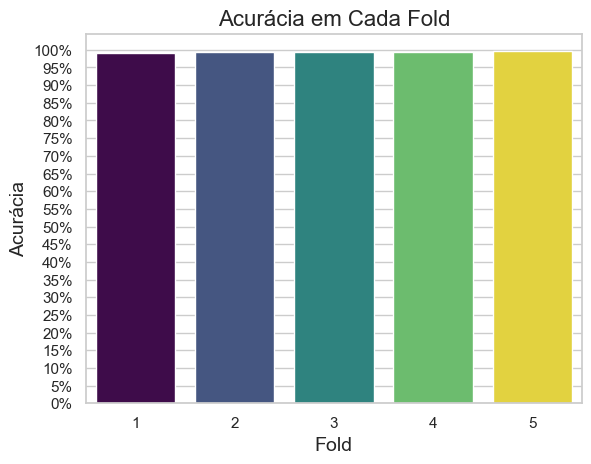

In [31]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)
plt.gca().set_yticks([i / 100 for i in range(100, -1, -5)])
plt.gca().set_yticklabels([f'{i}%' for i in range(100, -1, -5)])
plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
plt.show()

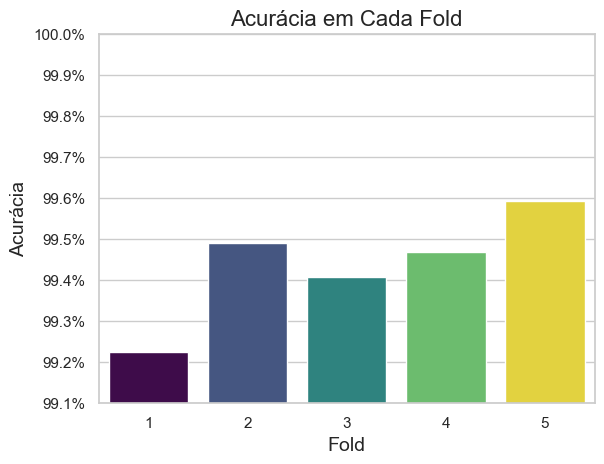

In [32]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)

# Ajustando os ticks do eixo y
plt.gca().set_yticks([i / 1000 for i in range(991, 1001)])  # De 99.1 a 100.0
plt.gca().set_yticklabels([f'{i / 10:.1f}%' for i in range(991, 1001)])  # Labels de 99.1% a 100.0%

# Definindo os limites do eixo y
plt.ylim(0.991, 1.000)  # Limite entre 99.1% e 100.0%

plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
plt.show()

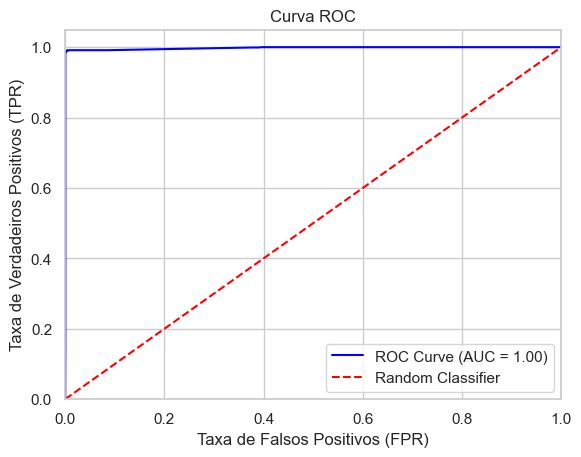

In [33]:
y_proba = model_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [34]:
jb.dump(model, 'model_word2vec.pkl')
jb.dump(model_rf, 'model_rf_word2vec.pkl')

['model_rf_word2vec.pkl']

# Métricas TF_IDF x Word2Vec -> Tempo de Vetorização e Tempo de Treinamento

#### TF_IDF

Tempo de Vetorização: 0.27167177200317383 segundos\
Tempo de Treinamento: 0.22006750106811523 segundos

#### Word2Vec

Tempo de Vetorização: 1.3120837211608887 segundos\
Tempo de Treinamento: 1.5795087814331055 segundos

# Métricas TF_IDF x Word2Vec -> Tempo de Execução, Ram, CPU (Sem Paralelismo)

## TF-IDF

SQL Nomal: 19390\
SQL Injection: 11218\
Total: 30608\
Tempo de execução: 40.2596 segundos\
Uso de memória inicial: 152.64 MB\
Uso de memória final: 154.42 MB\
Uso de CPU inicial: 0.0%\
Uso de CPU final: 99.4%

## Word2Vec

SQL Nomal: 19349\
SQL Injection: 11259\
Total: 30608\
Tempo de execução: 17.8674 segundos\
Uso de memória inicial: 193.36 MB\
Uso de memória final: 194.01 MB\
Uso de CPU inicial: 0.0%\
Uso de CPU final: 99.9%

# Métricas TF_IDF x Word2Vec -> Tempo de Execução, Ram, CPU (Com Paralelismo)

## TF-IDF

SQL Normal: 19390\
SQL Injection: 11218\
Total: 30608\
Tempo de execução: 11.7496 segundos\
Uso de memória inicial: 155.07 MB\
Uso de memória final: 156.77 MB\
Uso de CPU inicial por núcleo: [5.1, 3.0, 1.0, 1.0]\
Uso de CPU final por núcleo: [93.3, 99.8, 91.2, 92.3]\
Uso total de CPU inicial: 10.1%\
Uso total de CPU final: 94.15%

## Word2Vec

SQL Normal: 19349\
SQL Injection: 11259\
Total: 30608\
Tempo de execução: 4.9109 segundos\
Uso de memória inicial: 193.81 MB\
Uso de memória final: 196.16 MB\
Uso de CPU inicial por núcleo: [1.0, 3.1, 1.0, 5.0]\
Uso de CPU final por núcleo: [94.5, 99.4, 91.9, 90.6]\
Uso total de CPU inicial: 10.1%\
Uso total de CPU final: 94.1%

# Próximos Passos

1. Outliers
2. Parar a divisão se não melhorar a divisão (gini impureza)
3. Analisar Variância
4. Verificar se existe alguma forma de analisar a correlação com o alvo
5. Em relação aos Testes, verificar o polars ao invés do pandas para deixar mais real os testes (Velocidade)
6. Analisar linguagem de programação de baixo adequada para usar em web (Talvez Rust e WebAssembly)

# Extras / Anotações de Códigos

### Matriz dos TF-IDF e em forma de array

In [161]:
#MATRIZ TF-IDF

#vectorizer = TfidfVectorizer(use_idf=True)
#X_vectorizer = vectorizer.fit_transform(X)
#print(X_vectorizer.toarray())
#feature_names = vectorizer.get_feature_names_out()
#df = pd.DataFrame(X_vectorizer.todense(), columns=feature_names)
#display(df)

In [162]:
#ARRAY TF-IDF

#print(X_vectorizer.todense())
#print(type(X_vectorizer.todense()))
#X_dense = np.asarray(X_vectorizer.todense())
#print(type(X_dense))